In [1]:
import networkx as nx
import random
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
n = 12
G = nx.erdos_renyi_graph(n, 0.25, seed=42)
while not nx.is_connected(G):
    G = nx.erdos_renyi_graph(n, 0.25, seed=random.randint(0, 10000))

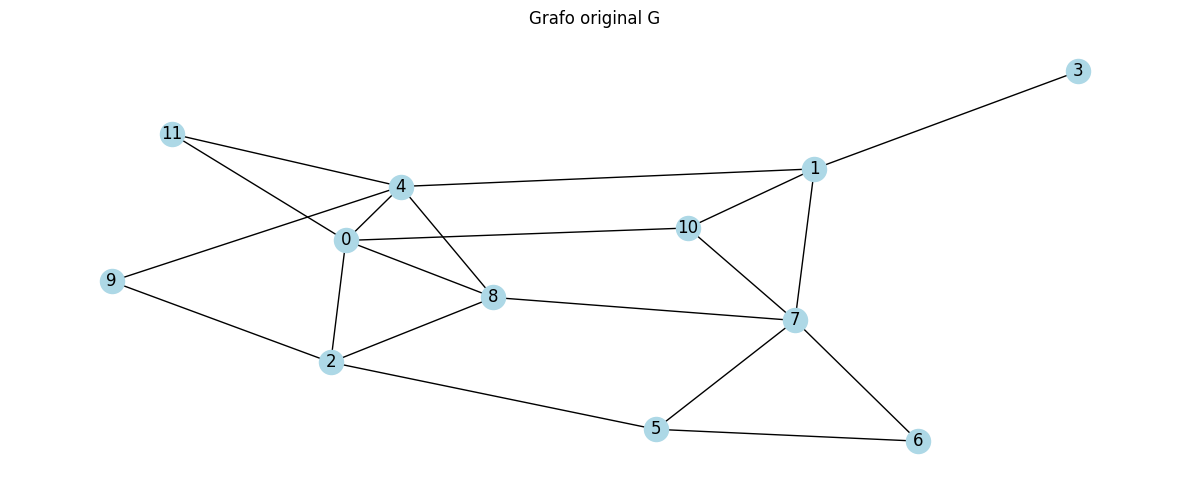

In [4]:
# ---------- Visualização ----------
pos = nx.spring_layout(G, seed=42)
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

nx.draw(G, pos, ax=ax, with_labels=True, node_color="lightblue")
ax.set_title("Grafo original G")

plt.tight_layout()
plt.show()

In [5]:
def single_walker_tree(G, start=None, seed=None):
    """
    Gera uma árvore geradora de G usando um único caminhante aleatório.
    A cada passo, o walker vai para um vizinho aleatório do vértice atual.
    Se o vizinho ainda não foi visitado, a aresta (atual -> vizinho) entra na árvore.
    """
    rng = random.Random(seed)

    if start is None:
        start = rng.choice(list(G.nodes()))

    visited = {start}
    tree_edges = []
    current = start
    steps = 0

    while len(visited) < G.number_of_nodes():
        neighbor = rng.choice(list(G.neighbors(current)))
        if neighbor not in visited:
            tree_edges.append((current, neighbor))
            visited.add(neighbor)
        current = neighbor
        steps += 1

    T = nx.Graph()
    T.add_nodes_from(G.nodes())
    T.add_edges_from(tree_edges)
    return T, steps

In [6]:
T, num_passos = single_walker_tree(G, seed=7)

print(f"Vértices: {G.number_of_nodes()}, Arestas do grafo: {G.number_of_edges()}")
print(f"Árvore gerada em {num_passos} passos do walker")
print("Arestas da árvore:", list(T.edges()))

Vértices: 12, Arestas do grafo: 20
Árvore gerada em 42 passos do walker
Arestas da árvore: [(0, 2), (0, 11), (0, 8), (0, 10), (1, 10), (1, 3), (1, 4), (2, 5), (2, 9), (5, 6), (7, 8)]


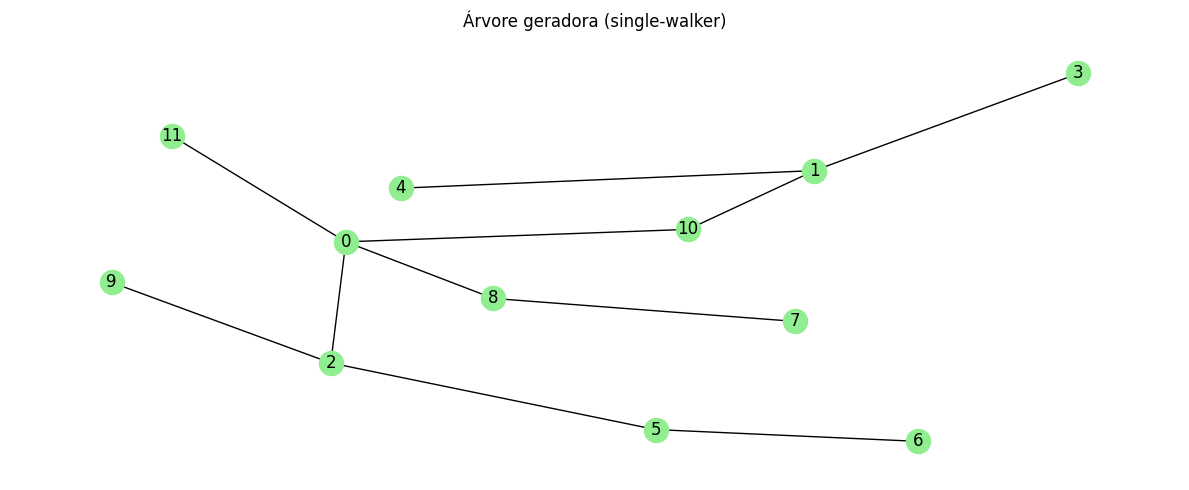

In [7]:
# ---------- Visualização ----------
pos = nx.spring_layout(G, seed=42)
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

nx.draw(T, pos, ax=ax, with_labels=True, node_color="lightgreen")
ax.set_title("Árvore geradora (single-walker)")


plt.tight_layout()
plt.show()

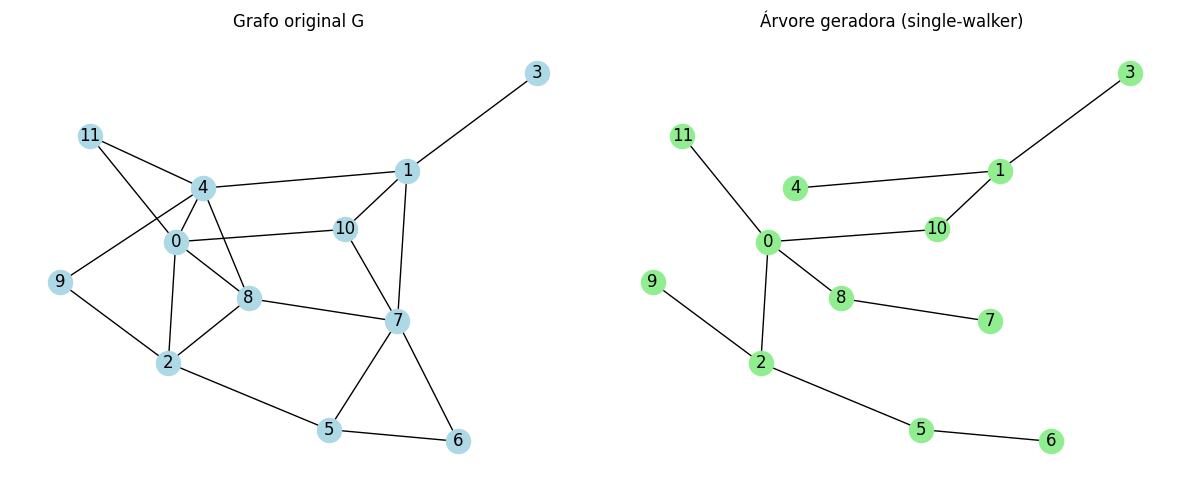

In [8]:
# ---------- Visualização ----------
pos = nx.spring_layout(G, seed=42)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

nx.draw(G, pos, ax=axes[0], with_labels=True, node_color="lightblue")
axes[0].set_title("Grafo original G")

nx.draw(T, pos, ax=axes[1], with_labels=True, node_color="lightgreen")
axes[1].set_title("Árvore geradora (single-walker)")

plt.tight_layout()
plt.show()

Vértices: 12, Arestas do grafo: 20
Arestas da árvore (Hadamard): [(0, 4), (0, 10), (0, 11), (1, 7), (1, 3), (2, 5), (2, 9), (4, 8), (5, 7), (5, 6), (7, 8)]
É árvore geradora válida? True


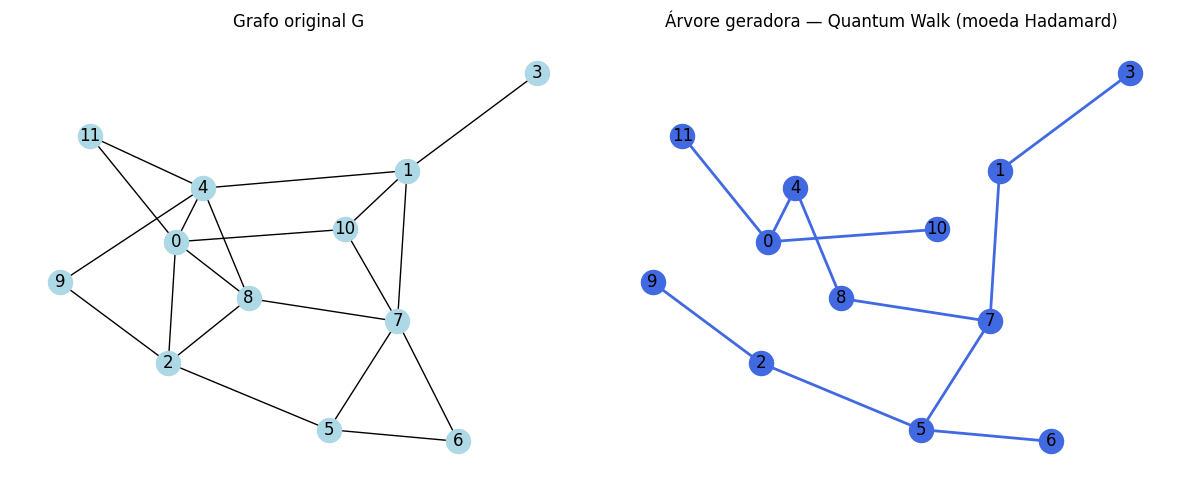

In [9]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt

# ---------- Grafo do usuário ----------
n = 12
G = nx.erdos_renyi_graph(n, 0.25, seed=42)
while not nx.is_connected(G):
    G = nx.erdos_renyi_graph(n, 0.25, seed=random.randint(0, 10000))

# ---------- Espaço de arcos ----------
def build_arcs(G):
    arcs = []
    for u, v in G.edges():
        arcs.append((u, v)); arcs.append((v, u))
    return arcs, {a: i for i, a in enumerate(arcs)}

# ---------- Moeda de Hadamard (generalizada via DFT p/ grau d qualquer) ----------
def hadamard_block(d):
    # para d=2 isso é EXATAMENTE [[1,1],[1,-1]]/sqrt(2)
    w = np.exp(2j * np.pi / d)
    idx = np.arange(d)
    return np.array([[w ** (a * b) for b in idx] for a in idx]) / np.sqrt(d)

def build_coin_operator(G, arcs, arc_index):
    dim = len(arcs)
    C = np.zeros((dim, dim), dtype=complex)
    for v in G.nodes():
        out_arcs = [(v, u) for u in G.neighbors(v)]
        d = len(out_arcs)
        if d == 0:
            continue
        idxs = [arc_index[a] for a in out_arcs]
        Cv = hadamard_block(d)
        for i, gi in enumerate(idxs):
            for j, gj in enumerate(idxs):
                C[gi, gj] = Cv[i, j]
    return C

def build_shift_operator(arcs, arc_index):
    dim = len(arcs)
    S = np.zeros((dim, dim))
    for (u, v), i in arc_index.items():
        S[arc_index[(v, u)], i] = 1
    return S

def vertex_marginal(psi, arc_index, nodes):
    probs = np.abs(psi) ** 2
    vp = {v: 0.0 for v in nodes}
    for (u, v), i in arc_index.items():
        vp[u] += probs[i]
    return vp

# ---------- Árvore geradora via quantum walk (moeda Hadamard) ----------
def hadamard_tree(G, start=None, seed=None, coin_steps=2):
    rng = random.Random(seed)
    if start is None:
        start = rng.choice(list(G.nodes()))

    arcs, arc_index = build_arcs(G)
    C = build_coin_operator(G, arcs, arc_index)
    S = build_shift_operator(arcs, arc_index)
    U = S @ C

    psi = np.zeros(len(arcs), dtype=complex)
    neigh = list(G.neighbors(start))
    for u in neigh:
        psi[arc_index[(start, u)]] = 1 / np.sqrt(len(neigh))

    visited = {start}
    tree_edges = []

    while len(visited) < G.number_of_nodes():
        for _ in range(coin_steps):
            psi = U @ psi

        vp = vertex_marginal(psi, arc_index, G.nodes())
        frontier = [v for v in G.nodes() if v not in visited and
                    any(x in visited for x in G.neighbors(v))]
        if not frontier:
            break

        weights = np.array([vp[v] for v in frontier])
        weights = weights / weights.sum() if weights.sum() > 1e-12 else np.ones(len(frontier)) / len(frontier)

        chosen = rng.choices(frontier, weights=weights, k=1)[0]
        parent = rng.choice([x for x in G.neighbors(chosen) if x in visited])

        tree_edges.append((parent, chosen))
        visited.add(chosen)

    T = nx.Graph()
    T.add_nodes_from(G.nodes())
    T.add_edges_from(tree_edges)
    return T


# ---------- Execução ----------
T = hadamard_tree(G, seed=7, coin_steps=2)

print(f"Vértices: {G.number_of_nodes()}, Arestas do grafo: {G.number_of_edges()}")
print("Arestas da árvore (Hadamard):", list(T.edges()))
print("É árvore geradora válida?", nx.is_tree(T) and T.number_of_nodes() == G.number_of_nodes())

# ---------- Visualização ----------
pos = nx.spring_layout(G, seed=42)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

nx.draw(G, pos, ax=axes[0], with_labels=True, node_color="lightblue")
axes[0].set_title("Grafo original G")

nx.draw(T, pos, ax=axes[1], with_labels=True, node_color="royalblue", edge_color="royalblue", width=2)
axes[1].set_title("Árvore geradora — Quantum Walk (moeda Hadamard)")

plt.tight_layout()
plt.show()

Vértices: 12, Arestas do grafo: 20
Peso total da MST: 52
Arestas da árvore: [(0, 4), (4, 8), (7, 8), (2, 9), (1, 10), (4, 9), (1, 4), (1, 3), (4, 11), (5, 6), (5, 7)]


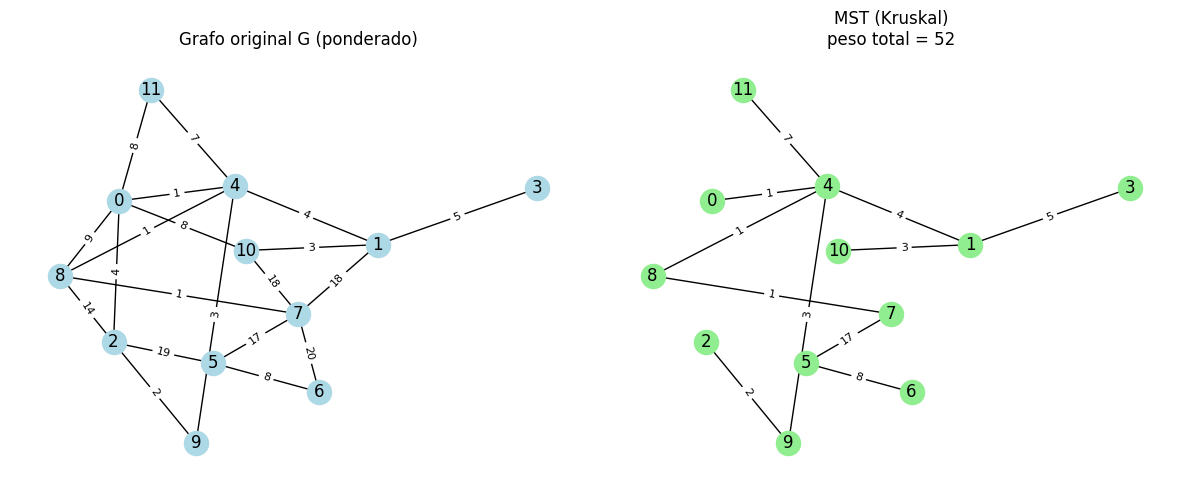

In [10]:
class UnionFind:
    def __init__(self, nodes):
        self.parent = {v: v for v in nodes}

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]  # compressão de caminho
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return False  # já conectados -> formaria ciclo
        self.parent[ra] = rb
        return True

def kruskal_tree(G):
    """
    Gera a árvore geradora MÍNIMA de G usando o algoritmo de Kruskal.
    Ordena as arestas por peso e vai unindo componentes, descartando
    qualquer aresta que formaria um ciclo.
    """
    edges = sorted(G.edges(data=True), key=lambda e: e[2]['weight'])
    uf = UnionFind(G.nodes())
    tree_edges = []

    for u, v, data in edges:
        if uf.union(u, v):
            tree_edges.append((u, v, data['weight']))
        if len(tree_edges) == G.number_of_nodes() - 1:
            break

    T = nx.Graph()
    T.add_nodes_from(G.nodes())
    T.add_weighted_edges_from(tree_edges)
    return T, tree_edges


# ---------- Exemplo de uso ----------
# Cria um grafo conexo aleatório e ponderado
n = 12
G = nx.erdos_renyi_graph(n, 0.25, seed=42)
while not nx.is_connected(G):
    G = nx.erdos_renyi_graph(n, 0.25, seed=random.randint(0, 10000))

rng = random.Random(42)
for u, v in G.edges():
    G[u][v]['weight'] = rng.randint(1, 20)

T, tree_edges = kruskal_tree(G)
total_weight = sum(w for _, _, w in tree_edges)

print(f"Vértices: {G.number_of_nodes()}, Arestas do grafo: {G.number_of_edges()}")
print(f"Peso total da MST: {total_weight}")
print("Arestas da árvore:", [(u, v) for u, v, w in tree_edges])

# ---------- Visualização ----------
pos = nx.spring_layout(G, seed=42)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw(G, pos, ax=axes[0], with_labels=True, node_color="lightblue")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=axes[0], font_size=8)
axes[0].set_title("Grafo original G (ponderado)")

nx.draw(T, pos, ax=axes[1], with_labels=True, node_color="lightgreen")
nx.draw_networkx_edge_labels(T, pos, edge_labels=nx.get_edge_attributes(T, 'weight'), ax=axes[1], font_size=8)
axes[1].set_title(f"MST (Kruskal)\npeso total = {total_weight}")

plt.tight_layout()
plt.show()

In [17]:
def run(run_seed=None, run_start=None):
    # ---------- Grafo conexo aleatório e ponderado ----------
    n = 12
    G = nx.erdos_renyi_graph(n, 0.25, seed=42)          # <- grafo continua FIXO (mesma estrutura)
    while not nx.is_connected(G):
        G = nx.erdos_renyi_graph(n, 0.25, seed=random.randint(0, 10000))

    rng = random.Random(42)                              # <- pesos continuam FIXOS (mesma comparação justa)
    for u, v in G.edges():
        G[u][v]['weight'] = rng.randint(1, 20)

    # ---------- Executa os dois algoritmos ----------
    T_kruskal, kruskal_edges = kruskal_tree(G)
    kruskal_weight = sum(w for _, _, w in kruskal_edges)

    # aqui é o que muda a cada execução:
    start = run_start if run_start is not None else random.choice(list(G.nodes()))
    T_hadamard, hadamard_edges = hadamard_tree(G, start=start, seed=run_seed, coin_steps=2)
    hadamard_weight = sum(w for _, _, w in hadamard_edges)

    print(f"Vértices: {G.number_of_nodes()}, Arestas do grafo: {G.number_of_edges()}")
    print(f"\nKruskal  -> peso total = {kruskal_weight}  (ótimo garantido)")
    print(f"Hadamard (start={start}, seed={run_seed}) -> peso total = {hadamard_weight}")
    print(f"Diferença: {hadamard_weight - kruskal_weight} "
          f"({100*(hadamard_weight - kruskal_weight)/kruskal_weight:.1f}% acima do ótimo)")

    # ---------- Visualização ----------
    pos = nx.spring_layout(G, seed=42)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    nx.draw(G, pos, ax=axes[0], with_labels=True, node_color="lightblue")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=axes[0], font_size=7)
    axes[0].set_title("Grafo original G (ponderado)")

    nx.draw(G, pos, ax=axes[1], edge_color="lightgray", node_color="lightgray")
    nx.draw(T_kruskal, pos, ax=axes[1], with_labels=True, node_color="lightgreen",
            edge_color="green", width=2.5)
    nx.draw_networkx_edge_labels(T_kruskal, pos, edge_labels=nx.get_edge_attributes(T_kruskal, 'weight'),
                                  ax=axes[1], font_size=7)
    axes[1].set_title(f"MST (Kruskal)\npeso total = {kruskal_weight}")

    nx.draw(G, pos, ax=axes[2], edge_color="lightgray", node_color="lightgray")
    nx.draw(T_hadamard, pos, ax=axes[2], with_labels=True, node_color="lightsalmon",
            edge_color="royalblue", width=2.5)
    nx.draw_networkx_edge_labels(T_hadamard, pos, edge_labels=nx.get_edge_attributes(T_hadamard, 'weight'),
                                  ax=axes[2], font_size=7)
    axes[2].set_title(f"Quantum Walk (Hadamard)\npeso total = {hadamard_weight}")

    plt.tight_layout()
    plt.show()


EXECUÇÃO 0
Vértices: 12, Arestas do grafo: 20

Kruskal  -> peso total = 52  (ótimo garantido)
Hadamard (start=5, seed=100) -> peso total = 79
Diferença: 27 (51.9% acima do ótimo)


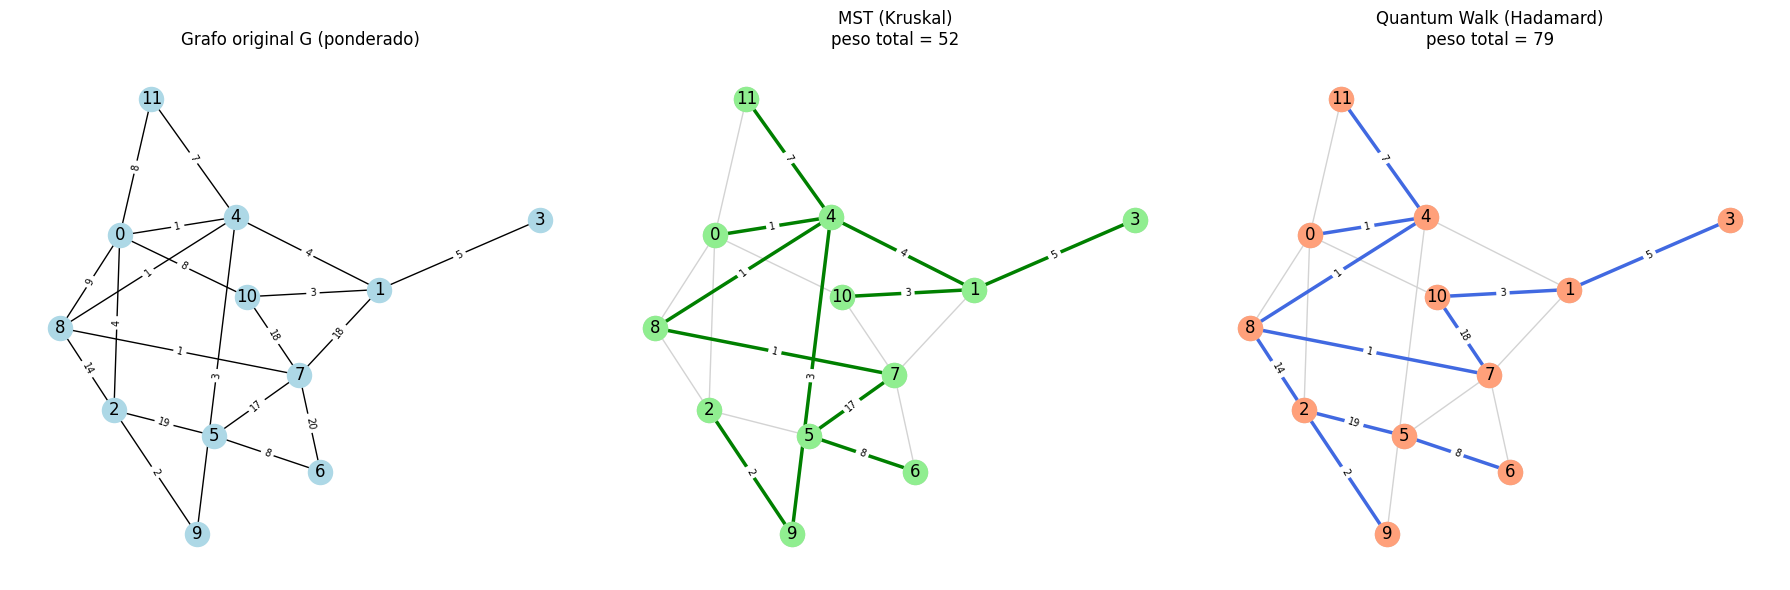


EXECUÇÃO 1
Vértices: 12, Arestas do grafo: 20

Kruskal  -> peso total = 52  (ótimo garantido)
Hadamard (start=3, seed=101) -> peso total = 52
Diferença: 0 (0.0% acima do ótimo)


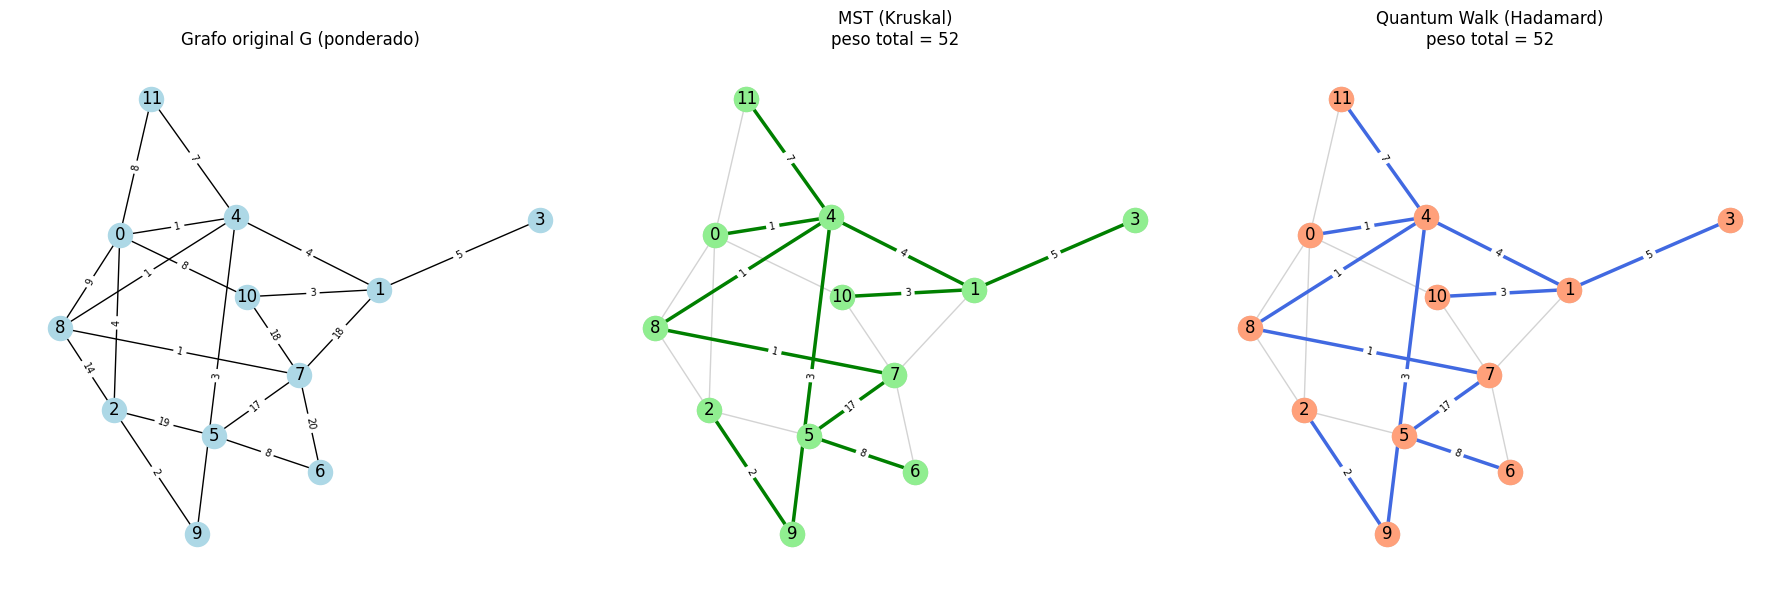


EXECUÇÃO 2
Vértices: 12, Arestas do grafo: 20

Kruskal  -> peso total = 52  (ótimo garantido)
Hadamard (start=3, seed=102) -> peso total = 70
Diferença: 18 (34.6% acima do ótimo)


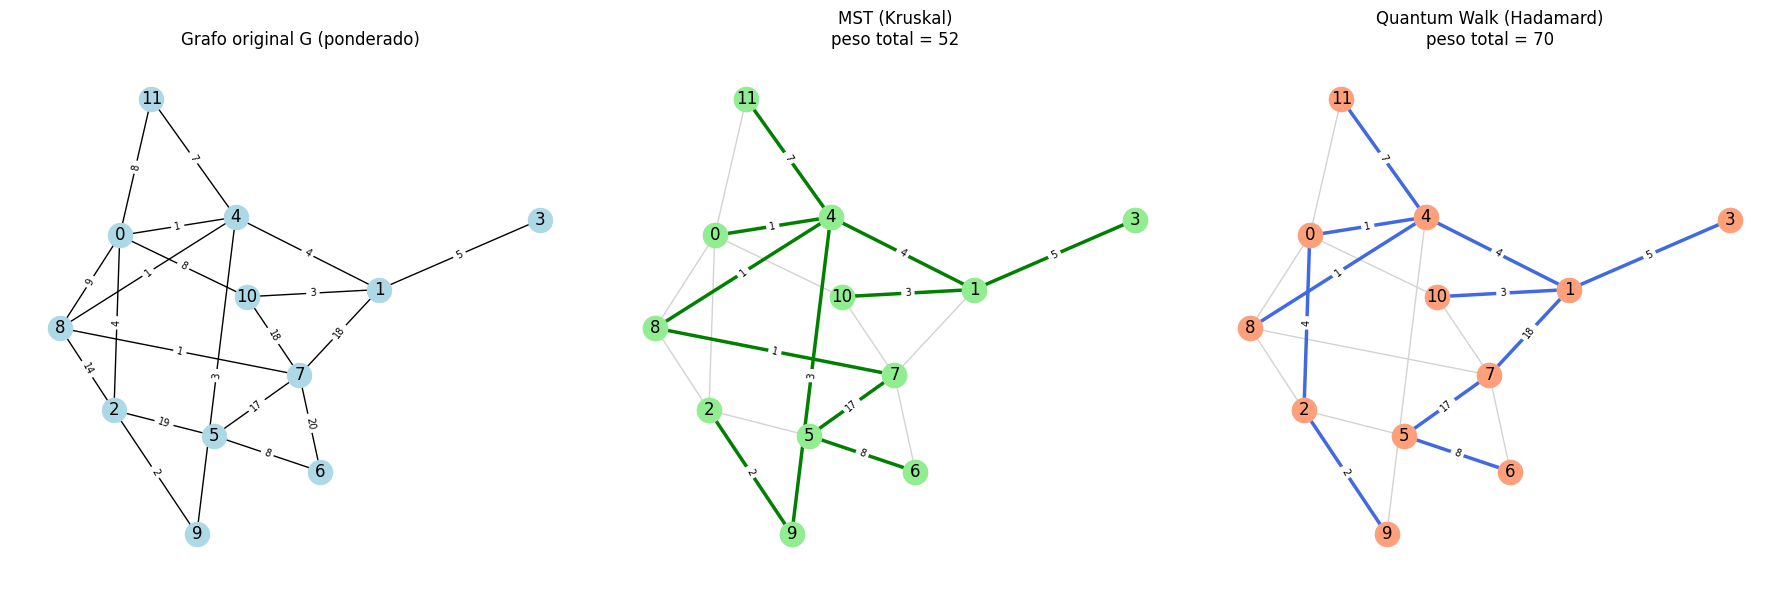


EXECUÇÃO 3
Vértices: 12, Arestas do grafo: 20

Kruskal  -> peso total = 52  (ótimo garantido)
Hadamard (start=1, seed=103) -> peso total = 68
Diferença: 16 (30.8% acima do ótimo)


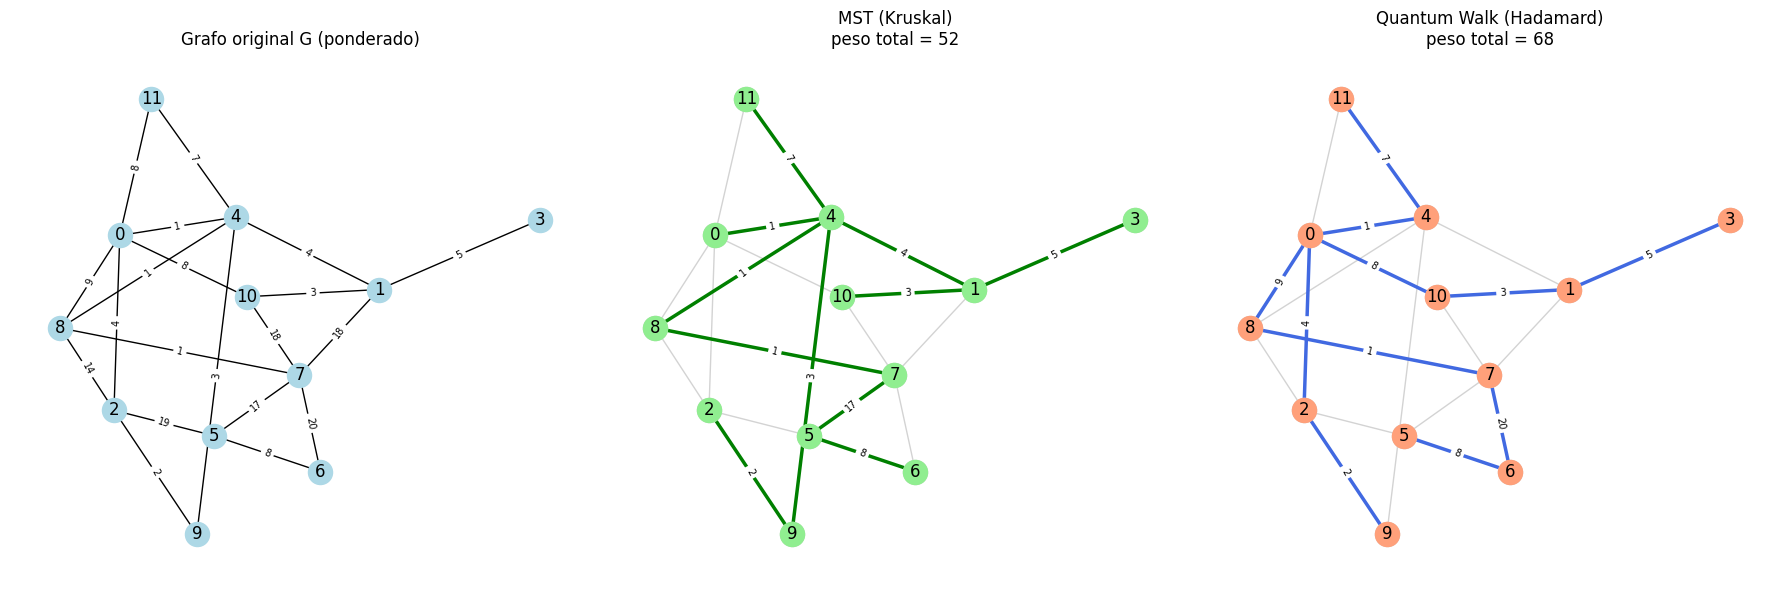

In [18]:
for i in range(4):
    print(f"\n{'='*50}\nEXECUÇÃO {i}\n{'='*50}")
    run(run_seed=100 + i)          # cada i gera uma seed distinta -> Hadamard diferente

In [20]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import networkx as nx
import random

# ===================== Grafo ponderado (fixo p/ comparação justa) =====================
n = 12
G = nx.erdos_renyi_graph(n, 0.25, seed=42)
while not nx.is_connected(G):
    G = nx.erdos_renyi_graph(n, 0.25, seed=random.randint(0, 10000))

rng_w = random.Random(42)
for u, v in G.edges():
    G[u][v]['weight'] = rng_w.randint(1, 20)

NODES = list(G.nodes())
N = len(NODES)

# ===================== MST exata (referência) =====================
class UnionFind:
    def __init__(self, nodes):
        self.parent = {v: v for v in nodes}
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb: return False
        self.parent[ra] = rb
        return True

def kruskal_weight(G):
    edges = sorted(G.edges(data=True), key=lambda e: e[2]['weight'])
    uf = UnionFind(G.nodes())
    total, count = 0, 0
    for u, v, data in edges:
        if uf.union(u, v):
            total += data['weight']; count += 1
        if count == G.number_of_nodes() - 1:
            break
    return total

MST_OPTIMAL = kruskal_weight(G)

# ===================== Espaço de arcos (Hadamard / Grover / Lackadaisical) =====================
def build_arcs(G, self_loops=False):
    arcs = []
    for u, v in G.edges():
        arcs.append((u, v)); arcs.append((v, u))
    if self_loops:
        for v in G.nodes():
            arcs.append((v, v))
    return arcs, {a: i for i, a in enumerate(arcs)}

def grover_block(d):
    J = np.ones((d, d))
    return 2 / d * J - np.eye(d)

def dft_block(d):
    w = np.exp(2j * np.pi / d)
    idx = np.arange(d)
    return np.array([[w ** (a * b) for b in idx] for a in idx]) / np.sqrt(d)

def build_coin_arc(G, arcs, arc_index, block_fn, self_loops=False):
    dim = len(arcs)
    C = np.zeros((dim, dim), dtype=complex)
    for v in G.nodes():
        out_arcs = [(v, u) for u in G.neighbors(v)]
        if self_loops:
            out_arcs.append((v, v))
        d = len(out_arcs)
        if d == 0: continue
        idxs = [arc_index[a] for a in out_arcs]
        Cv = block_fn(d)
        for i, gi in enumerate(idxs):
            for j, gj in enumerate(idxs):
                C[gi, gj] = Cv[i, j]
    return C

def build_shift_arc(arcs, arc_index):
    dim = len(arcs)
    S = np.zeros((dim, dim))
    for (u, v), i in arc_index.items():
        S[arc_index[(v, u)], i] = 1
    return S

def vertex_marginal_arc(psi, arc_index, nodes):
    probs = np.abs(psi) ** 2
    vp = {v: 0.0 for v in nodes}
    for (u, v), i in arc_index.items():
        vp[u] += probs[i]
    return vp

def build_lackadaisical(G):
    arcs, arc_index = build_arcs(G, self_loops=True)
    C = build_coin_arc(G, arcs, arc_index, grover_block, self_loops=True)
    S = build_shift_arc(arcs, arc_index)
    return arcs, arc_index, S @ C

# ===================== Szegedy (dimensão n x n) =====================
def build_szegedy(G):
    A = nx.to_numpy_array(G, nodelist=NODES)
    deg = A.sum(axis=1)
    P = A / deg[:, None]
    dim = N * N
    def idx(x, y): return x * N + y

    psi_vecs = np.zeros((N, dim))
    phi_vecs = np.zeros((N, dim))
    for x in range(N):
        for y in range(N):
            if P[x, y] > 0:
                psi_vecs[x, idx(x, y)] = np.sqrt(P[x, y])
                phi_vecs[y, idx(x, y)] = np.sqrt(P[x, y])

    R_A = 2 * (psi_vecs.T @ psi_vecs) - np.eye(dim)
    R_B = 2 * (phi_vecs.T @ phi_vecs) - np.eye(dim)
    return psi_vecs, R_B @ R_A

def szegedy_marginal(psi):
    probs = np.abs(psi) ** 2
    mat = probs.reshape(N, N)
    col_sum = mat.sum(axis=0)
    return {v: col_sum[i] for i, v in enumerate(NODES)}

# ===================== Staggered (tesselações via matchings) =====================
def build_tessellations(G):
    H = G.copy()
    tess = []
    while H.number_of_edges() > 0:
        M = nx.maximal_matching(H)
        tess.append(list(M))
        H.remove_edges_from(M)
    return tess

def tessellation_unitary(tess, node_index):
    U = np.eye(N, dtype=complex)
    for (u, v) in tess:
        i, j = node_index[u], node_index[v]
        U[i, i] = 0; U[j, j] = 0
        U[i, j] = 1; U[j, i] = 1
    return U

def build_staggered(G):
    node_index = {v: i for i, v in enumerate(NODES)}
    tess = build_tessellations(G)
    U_total = np.eye(N, dtype=complex)
    for t in tess:
        U_total = tessellation_unitary(t, node_index) @ U_total
    return U_total

# ===================== Construção da árvore -- interface comum =====================
def quantum_tree_weight(coin_type, start, seed, coin_steps):
    r = random.Random(seed)
    node_index = {v: i for i, v in enumerate(NODES)}

    if coin_type in ("hadamard", "grover"):
        arcs, arc_index = build_arcs(G, self_loops=False)
        block_fn = dft_block if coin_type == "hadamard" else grover_block
        C = build_coin_arc(G, arcs, arc_index, block_fn, self_loops=False)
        S = build_shift_arc(arcs, arc_index)
        U = S @ C
        psi = np.zeros(len(arcs), dtype=complex)
        neigh = list(G.neighbors(start))
        for u in neigh:
            psi[arc_index[(start, u)]] = 1 / np.sqrt(len(neigh))
        step = lambda p: U @ p
        marg = lambda p: vertex_marginal_arc(p, arc_index, NODES)

    elif coin_type == "lackadaisical":
        arcs, arc_index, U = build_lackadaisical(G)
        psi = np.zeros(len(arcs), dtype=complex)
        neigh = list(G.neighbors(start))
        d1 = len(neigh) + 1
        for u in neigh:
            psi[arc_index[(start, u)]] = 1 / np.sqrt(d1)
        psi[arc_index[(start, start)]] = 1 / np.sqrt(d1)
        step = lambda p: U @ p
        marg = lambda p: vertex_marginal_arc(p, arc_index, NODES)

    elif coin_type == "szegedy":
        psi_vecs, W = build_szegedy(G)
        psi = psi_vecs[node_index[start]].astype(complex)
        step = lambda p: W @ p
        marg = szegedy_marginal

    elif coin_type == "staggered":
        U_total = build_staggered(G)
        psi = np.zeros(N, dtype=complex)
        psi[node_index[start]] = 1.0
        step = lambda p: U_total @ p
        marg = lambda p: {v: np.abs(p[i]) ** 2 for i, v in enumerate(NODES)}

    else:
        raise ValueError(coin_type)

    visited = {start}
    total_weight = 0

    while len(visited) < G.number_of_nodes():
        for _ in range(coin_steps):
            psi = step(psi)

        vp = marg(psi)
        frontier = [v for v in G.nodes() if v not in visited and
                    any(x in visited for x in G.neighbors(v))]
        if not frontier:
            break

        wv = np.array([vp[v] for v in frontier])
        wv = wv / wv.sum() if wv.sum() > 1e-12 else np.ones(len(frontier)) / len(frontier)

        chosen = r.choices(frontier, weights=wv, k=1)[0]
        candidates = [(x, G[chosen][x]['weight']) for x in G.neighbors(chosen) if x in visited]
        parent, wgt = min(candidates, key=lambda t: t[1])

        total_weight += wgt
        visited.add(chosen)

    return total_weight

# ===================== Executa cada moeda várias vezes (mesma ideia do for i in range) =====================
def run(coin_type, run_seed, run_start=None, coin_steps=2):
    start = run_start if run_start is not None else random.choice(NODES)
    weight = quantum_tree_weight(coin_type, start, run_seed, coin_steps)
    return weight

COINS = ["hadamard", "grover", "lackadaisical", "szegedy", "staggered"]
N_EXECUCOES = 4

results = {}
print(f"MST ótima (Kruskal) = {MST_OPTIMAL}\n")

for coin in COINS:
    weights = []
    for i in range(N_EXECUCOES):
        w = run(coin, run_seed=100 + i, coin_steps=2)
        weights.append(w)
        print(f"[{coin:13s}] execução {i} (seed={100+i}) -> peso = {w}")
    results[coin] = weights
    print(f"  -> média = {np.mean(weights):.1f} | melhor = {min(weights)}\n")

# ===================== Melhor método quântico encontrado =====================
best_coin = min(results, key=lambda c: min(results[c]))
best_weight = min(results[best_coin])
best_run_idx = results[best_coin].index(best_weight)
best_seed = 100 + best_run_idx

print("=" * 55)
print(f"MELHOR MÉTODO QUÂNTICO: {best_coin.upper()}")
print(f"  seed usada        : {best_seed}")
print(f"  peso obtido       : {best_weight}")
print(f"  peso ótimo (MST)  : {MST_OPTIMAL}")
print(f"  diferença         : {best_weight - MST_OPTIMAL} "
      f"({100*(best_weight - MST_OPTIMAL)/MST_OPTIMAL:.1f}% acima do ótimo)")
print("=" * 55)

MST ótima (Kruskal) = 52

[hadamard     ] execução 0 (seed=100) -> peso = 66
[hadamard     ] execução 1 (seed=101) -> peso = 70
[hadamard     ] execução 2 (seed=102) -> peso = 75
[hadamard     ] execução 3 (seed=103) -> peso = 53
  -> média = 66.0 | melhor = 53

[grover       ] execução 0 (seed=100) -> peso = 54
[grover       ] execução 1 (seed=101) -> peso = 69
[grover       ] execução 2 (seed=102) -> peso = 75
[grover       ] execução 3 (seed=103) -> peso = 69
  -> média = 66.8 | melhor = 54

[lackadaisical] execução 0 (seed=100) -> peso = 57
[lackadaisical] execução 1 (seed=101) -> peso = 66
[lackadaisical] execução 2 (seed=102) -> peso = 76
[lackadaisical] execução 3 (seed=103) -> peso = 74
  -> média = 68.2 | melhor = 57

[szegedy      ] execução 0 (seed=100) -> peso = 71
[szegedy      ] execução 1 (seed=101) -> peso = 88
[szegedy      ] execução 2 (seed=102) -> peso = 85
[szegedy      ] execução 3 (seed=103) -> peso = 73
  -> média = 79.2 | melhor = 71

[staggered    ] execução 0